<h1>NAO Index</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import gc
import collections
from io import BytesIO
from PIL import Image
import scipy
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.regridder import Regrid
from src.util import util, oni, timeutil, stats

<h5>User Configurables</h5>

In [3]:
ufs_experiment = 'baseline'

In [4]:
ufs_var = 'slp'
era5_var = 'mean_sea_level_pressure'

In [5]:
time_range = ("1994-01-01", "2021-12-31T23")
initmonth = 11

# Form Composites around these leads.
# You could also specify a single lead, like, leads=1
leads = (0, 1, 2, 3)

In [6]:
# For NAO, there are 2 reference locations:
region_1 = {'latmin': 65.0, 'lonmin': 331.2}
region_2 = {'latmin': 37.7, 'lonmin': 334.3}

In [7]:
# Transform leads into a tuple used for slicing.
if isinstance(leads, int):
    leads = tuple([leads])

<h3>First step is to calculate NAO Index</h3>

<h5>Get data readers</h5>

In [8]:
ufs_data_reader = dr.getDataReader(datasource='UFS',
                                   #filename=f"experiments/phase_1/{ufs_experiment}/atm_monthly.zarr",
                                   experiment=ufs_experiment,
                                   model='atm')

era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr
No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [9]:
ufs_data_reader.describe(ufs_var)


Variable: slp
Dimensions: ('init', 'lead', 'member', 'lat', 'lon')
Shape: (60, 4, 11, 192, 384)
Attributes:
  - long_name: Pressure reduced to MSL
  - units: Pa


In [10]:
era5_data_reader.describe(era5_var)


Variable: mean_sea_level_pressure
Dimensions: ('time', 'lat', 'lon')
Shape: (92044, 256, 512)
Attributes:
  - long_name: Mean sea level pressure
  - short_name: msl
  - standard_name: air_pressure_at_mean_sea_level
  - units: Pa


In [11]:
ufs_ds_1 = ufs_data_reader.retrieve(var=ufs_var, time=time_range, initmonths=initmonth,
                                    lat=region_1['latmin'], lon=region_1['lonmin'],
                                    lead=(min(leads), max(leads)),
                                    ens_avg=True).load()  # load

ufs_ds_2 = ufs_data_reader.retrieve(var=ufs_var, time=time_range, initmonths=initmonth,
                                    lat=region_2['latmin'], lon=region_2['lonmin'],
                                    lead=(min(leads), max(leads)),
                                    ens_avg=True).load()  # load

Taking Ensemble Average
Taking Ensemble Average


<h5>Get the corresponding ERA5 data</h5>

In [12]:
era5_ds_1 = era5_data_reader.retrieve(var=era5_var,
                                      lat=region_1['latmin'], lon=region_1['lonmin']).load()

era5_ds_2 = era5_data_reader.retrieve(var=era5_var,
                                      lat=region_2['latmin'], lon=region_2['lonmin']).load()

In [13]:
# Ensure that temporal domains perfectly match.
era5_ds_1 = timeutil.match_time_to_leads(verif_ds=era5_ds_1,
                                         ufs_ds=ufs_ds_1).load()  # load

era5_ds_2 = timeutil.match_time_to_leads(verif_ds=era5_ds_2,
                                         ufs_ds=ufs_ds_2).load()  # load

<h5>Calculate climatologies for each dataset (this may take a couple minutes)</h5>

In [14]:
ufs_stats_1 = stats.calc_climatology_anomaly(ufs_ds_1, area_mean=False, use_member_climatology=False)
ufs_stats_2 = stats.calc_climatology_anomaly(ufs_ds_2, area_mean=False, use_member_climatology=False)

In [15]:
era5_stats_1 = stats.calc_climatology_anomaly(era5_ds_1, area_mean=False)
era5_stats_2 = stats.calc_climatology_anomaly(era5_ds_2, area_mean=False)

<h5>Normalize the data.  z = (X - mu) / sigma</h5>

In [16]:
# Normalize UFS datasets
ufs_da_1 = stats.normalize(da=ufs_ds_1[ufs_var], stats=ufs_stats_1)
ufs_da_2 = stats.normalize(da=ufs_ds_2[ufs_var], stats=ufs_stats_2)

In [17]:
# Normalize VERIF datasets
era5_da_1 = stats.normalize(da=era5_stats_1['monthly_mean'], stats=era5_stats_1)
era5_da_2 = stats.normalize(da=era5_stats_2['monthly_mean'], stats=era5_stats_2)

<h2>Calculate NAO Index</h2>

<h5>Take difference between 2 locations and store result into new datasets</h5>

In [18]:
ufs_da_1 = ufs_da_1.squeeze(['lat', 'lon'])  # flatten
ufs_da_2 = ufs_da_2.squeeze(['lat', 'lon'])
era5_da_1 = era5_da_1.squeeze(['lat', 'lon'])
era5_da_2 = era5_da_2.squeeze(['lat', 'lon'])

In [19]:
ufs_ds_nao = (ufs_da_2 - ufs_da_1).to_dataset()
era5_ds_nao = (era5_da_2 - era5_da_1).to_dataset()

<h2>Now that NAO Index is calculated, we can form 2m-temperature composites</h2>

<h5>First, classify which forecast leads (UFS) or times (Verif) are in positive or negative phase</h5>

In [20]:
all_times = list(era5_ds_nao.time.values)
keep_these_times_index = []

# Match VERIF times to UFS init+leads
# These are the UFS months to match:
ufs_months_to_match = [util.add_month_number(month_number=initmonth, lead=this_lead)
                       for this_lead in leads]

# Get the VERIF times that match UFS
for i in range(len(all_times)):
    
    this_time = all_times[i]
    this_month_number = pd.to_datetime(this_time).month

    if this_month_number in ufs_months_to_match:
        keep_these_times_index.append(i)

# Subset all VERIF times
keep_these_times = [all_times[i] for i in keep_these_times_index]

In [21]:
# Sel VERIF NAO dataset to match UFS leads without any additional temporal coverage.
era5_ds_nao = era5_ds_nao.sel(time=keep_these_times)

In [22]:
# This is when ERA5 NAO is positive or negative
era5_positive_exclude_initleads = []
era5_negative_exclude_initleads = []

for i in range(len(era5_ds_nao.time.values)):
    this_time = era5_ds_nao.time.values[i]
    
    this_month_number = pd.to_datetime(this_time).month
    
    # two cases for handling calendar months
    if this_month_number >= initmonth:
        this_lead = this_month_number - initmonth
    else:
        this_lead = this_month_number + (12-initmonth)
    
    # Get the corresponding init time
    this_init = timeutil.time_offset(freq_unit='MS',
                                     init=this_time,
                                     lead=this_lead,
                                     step=np.timedelta64(30, 'D'),
                                     direction='backward')
    
    this_nao_value = era5_ds_nao[era5_var].sel(time=this_time).values.item()
    
    # Convert this time to an init_lead
    if this_nao_value >= 0:
        era5_negative_exclude_initleads.append((this_init, this_lead))

    elif this_nao_value <= 0:
        era5_positive_exclude_initleads.append((this_init, this_lead))

In [23]:
# This is when UFS NAO is positive or negative
ufs_positive_exclude_initleads = []
ufs_negative_exclude_initleads = []

for i in range(len(ufs_ds_nao.init.values)):
    this_init = ufs_ds_nao.init.values[i]
    
    for j in range(len(ufs_ds_nao.lead.values)):
        this_lead = ufs_ds_nao.lead.values[j]
        
        this_nao_value = ufs_ds_nao[ufs_var].sel(init=this_init, lead=this_lead).values.item()
            
        if this_nao_value >= 0:
            ufs_positive_exclude_initleads.append((this_init, this_lead))
            
        elif this_nao_value <= 0:
            ufs_negative_exclude_initleads.append((this_init, this_lead))

<h3>Compute 2-meter temperature composite</h3>

In [24]:
ufs_var = 'tmp2m'
era5_var = '2m_temperature'

In [25]:
# 1 indicator shall refer to VERIF data
data_reader1 = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [26]:
# 2 indicator shall refer to UFS data
data_reader2 = dr.getDataReader(datasource='UFS',                  
                                experiment = ufs_experiment,
                                # filename=f'experiments/phase_1/{ufs_experiment}/atm_monthly.zarr',                     
                                model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr


In [27]:
ds1 = data_reader1.retrieve(var=era5_var)

In [28]:
ds2 = data_reader2.retrieve(var=ufs_var,
                            time=time_range,
                            initmonths=initmonth,
                            lead=(min(leads), max(leads)),
                            ens_avg=True)

Taking Ensemble Average


In [29]:
# Ensure that temporal domains perfectly match.
ds1 = timeutil.match_time_to_leads(verif_ds=ds1,
                                   ufs_ds=ds2)

In [30]:
# Update datareaders with subsetted data.
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h5>Instantiate Regridder</h5>

In [31]:
regridder = Regrid.Regrid(data_reader1=data_reader1,                                                              
                          data_reader2=data_reader2,                                                            
                          method='linear')


Regrid Object initialized.

___Resample Instructions___
data_reader1 must be temporally resampled before spatially regridding.
Resample these data by running <RegridObj>.resample(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for resample, run <RegridObj>.resample_vars()

___Regrid Instructions___
Initialized the Regridder with method 'linear'
Input grid shape data_reader1 (ERA5_DataReader): lat 256, lon 512
Output grid shape data_reader2 (UFS_DataReader): lat 192, lon 384
Regrid these data by running <RegridObj>.regrid(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for regrid, run <RegridObj>.regrid_vars()

___Align Instructions___
data_reader1 can have its time coordinates converted to init+lead.
Lead resolution of the UFS dataset interpreted as monthly intervals.
Align these data by running <RegridObj>.align() (You may need to resample and/or regrid first.)



In [32]:
# Get vars to resample and regrid
vars_to_resample = era5_var
vars_to_regrid = list(globals()[f'data_reader{regridder.highres_grid}'].dataset().keys())
print(f'will resample {vars_to_resample}')
print(f'will regrid {vars_to_regrid}')

will resample 2m_temperature
will regrid ['2m_temperature']


In [33]:
# RESAMPLE.  (Give this a few minutes to complete.)
regridder.resample(var=vars_to_resample)

Resampling data_reader1 data to 'MS' using mean aggregation.
Resampling from 1994-11-01T00 to 2021-12-31T18
Number of cores available: 4
Finished multiprocessing.  Concatenating results.
Resample completed in 0.94 minutes.
Resample results stored in <RegridObj>.resampled


In [34]:
# REGRID.
regridder.regrid(var=vars_to_regrid)

Regridding data_reader1 grid (ERA5_DataReader) onto data_reader2 grid (UFS_DataReader)
Running scalar regrid on 2m_temperature
Completed scalar regrid in 0.04 minutes.
Regrid results stored in <RegridObj>.regridded


In [35]:
# ALIGN.
regridder.align()

Aligning time coordinate to init+lead coordinates.
MODEL_LEADS: [0 1 2 3]
Time dimensions aligned:  matched 110 timesteps
Align results stored in <RegridObj>.aligned


/home/thamzey/ufs-analysis/notebooks/sfs/nao/default/../../../../src/regridder/Regrid.py:805: UserWarning: Verif data not available for 2 timesteps, filled with NaN.
  warnings.warn(msg)


In [36]:
# Datasets have been pre-processed.
# Need some logic here to extract the results.

# For these notebooks, we know that Verif data are aligned:
ds1 = regridder.aligned.dataset()

# UFS data could be in the regridded slot or not, depending on the experiment we're working with.
if regridder.highres_grid == 2:
    ds2 = regridder.regridded.dataset()
else:
    ds2 = data_reader2.dataset()

In [37]:
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h3>Ready for ONI calculations!</h3>

In [38]:
ds1_positive_statistics = oni.calc_composite_layers(data_reader=data_reader1,
                                                    var=era5_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=era5_positive_exclude_initleads)

ds1_negative_statistics = oni.calc_composite_layers(data_reader=data_reader1,
                                                    var=era5_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=era5_negative_exclude_initleads)

ds2_positive_statistics = oni.calc_composite_layers(data_reader=data_reader2,
                                                    var=ufs_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=ufs_positive_exclude_initleads)

ds2_negative_statistics = oni.calc_composite_layers(data_reader=data_reader2,
                                                    var=ufs_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=ufs_negative_exclude_initleads)

Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.


<h3>Run t-tests</h3>

In [39]:
# Get position of init and lead axes
dims = list(ds1_positive_statistics['anomaly'].dims) 
ttest_axes = []
if 'init' in dims:
    ttest_axes.append(dims.index("init"))
if 'lead' in dims:
    ttest_axes.append(dims.index("lead"))

In [40]:
# POSITIVE
anomaly_tstatistic_positive, anomaly_pvalue_positive =\
    scipy.stats.ttest_ind(a=ds1_positive_statistics['anomaly'].values,
                          b=ds2_positive_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

# NEGATIVE
anomaly_tstatistic_negative, anomaly_pvalue_negative =\
    scipy.stats.ttest_ind(a=ds1_negative_statistics['anomaly'].values,
                          b=ds2_negative_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

<h5>Package statistics</h5>

In [41]:
p_values = xr.Dataset(
    data_vars={
        'anomaly_pvalue_positive': (('lat', 'lon'), anomaly_pvalue_positive),
        'anomaly_pvalue_negative': (('lat', 'lon'), anomaly_pvalue_negative)
        
    },
    coords={
        'lat': data_reader1.dataset().lat.values,
        'lon': data_reader1.dataset().lon.values
    }
)

<h1>Anomaly</h1>

In [42]:
# This is the DataArray for the Composite
ds1_positive_composite = ds1_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds1_negative_composite = ds1_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

ds2_positive_composite = ds2_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds2_negative_composite = ds2_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

# Calculate the difference in anomalies
positive_ds2_minus_ds1 = ds2_positive_composite - ds1_positive_composite
negative_ds2_minus_ds1 = ds2_negative_composite - ds1_negative_composite

# Calculate Correlations
positive_corr = xr.corr(ds1_positive_composite, ds2_positive_composite).values.item()
negative_corr = xr.corr(ds1_negative_composite, ds2_negative_composite).values.item()

<h5>Make labels for the plots</h5>

In [43]:
n_ufs_positive_phases = f"N Positive Phases: {len(ufs_negative_exclude_initleads)}"
n_ufs_negative_phases = f"N Negative Phases: {len(ufs_positive_exclude_initleads)}"

n_era5_positive_phases = f"N Positive Phases: {len(era5_negative_exclude_initleads)}"
n_era5_negative_phases = f"N Negative Phases: {len(era5_positive_exclude_initleads)}"

# Label for init and leads
initlead_label = f"init {initmonth}\nlead {' '.join(filter(str.isdigit, str(leads)))}"

# Label for correlation
positive_corr_label = f'corr: {positive_corr:.2f}'
negative_corr_label = f'corr: {negative_corr:.2f}'

<h3>Generate figures</h3>

In [44]:
%%capture captured_output

# Instantiate buffers
buffer1 = BytesIO()
buffer2 = BytesIO()
buffer3 = BytesIO()
buffer4 = BytesIO()
buffer5 = BytesIO()
buffer6 = BytesIO()

# Make 6 plots
plot_kwargs = {'cmap_label': 'mm day-1',
               'cmap': 'BrBG',
               'topleft_label': initlead_label, 
               'region': None,
               'dpi': 200}

plot1 = oni.plot_composite(da = ds1_positive_composite,
                           title=f'{data_reader1.datasource} T2m Anomaly (Positive NAO Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_era5_positive_phases, **plot_kwargs)

plt.savefig(buffer1, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot2 = oni.plot_composite(da = ds1_negative_composite,
                           title=f'{data_reader1.datasource} T2m Anomaly (Negative NAO Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_era5_negative_phases, **plot_kwargs)

plt.savefig(buffer2, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot3 = oni.plot_composite(da = ds2_positive_composite,
                           title=f'{data_reader2.datasource} T2m Anomaly (Positive NAO Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_ufs_positive_phases, **plot_kwargs)

plt.savefig(buffer3, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot4 = oni.plot_composite(da = ds2_negative_composite,
                           title=f'{data_reader2.datasource} T2m Anomaly (Negative NAO Phase)',
                           vmin=-6, vmax=6,
                           subtitle=n_ufs_negative_phases, **plot_kwargs)

plt.savefig(buffer4, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot5 = oni.plot_composite(da = positive_ds2_minus_ds1,
                           shading = p_values['anomaly_pvalue_positive'],
                           shading_threshold = 0.05,
                           title=f'{data_reader2.datasource} minus {data_reader1.datasource} T2m Anomaly (Positive NAO Phase)',
                           vmin=-4, vmax=4,
                           bottomright_label=positive_corr_label,
                           **plot_kwargs)

plt.savefig(buffer5, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot6 = oni.plot_composite(da = negative_ds2_minus_ds1,
                           shading = p_values['anomaly_pvalue_negative'],
                           shading_threshold = 0.05,
                           title=f'{data_reader2.datasource} minus {data_reader1.datasource} T2m Anomaly (Negative NAO Phase)',
                           vmin=-4, vmax=4,
                           bottomright_label=negative_corr_label,
                           **plot_kwargs)

plt.savefig(buffer6, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------


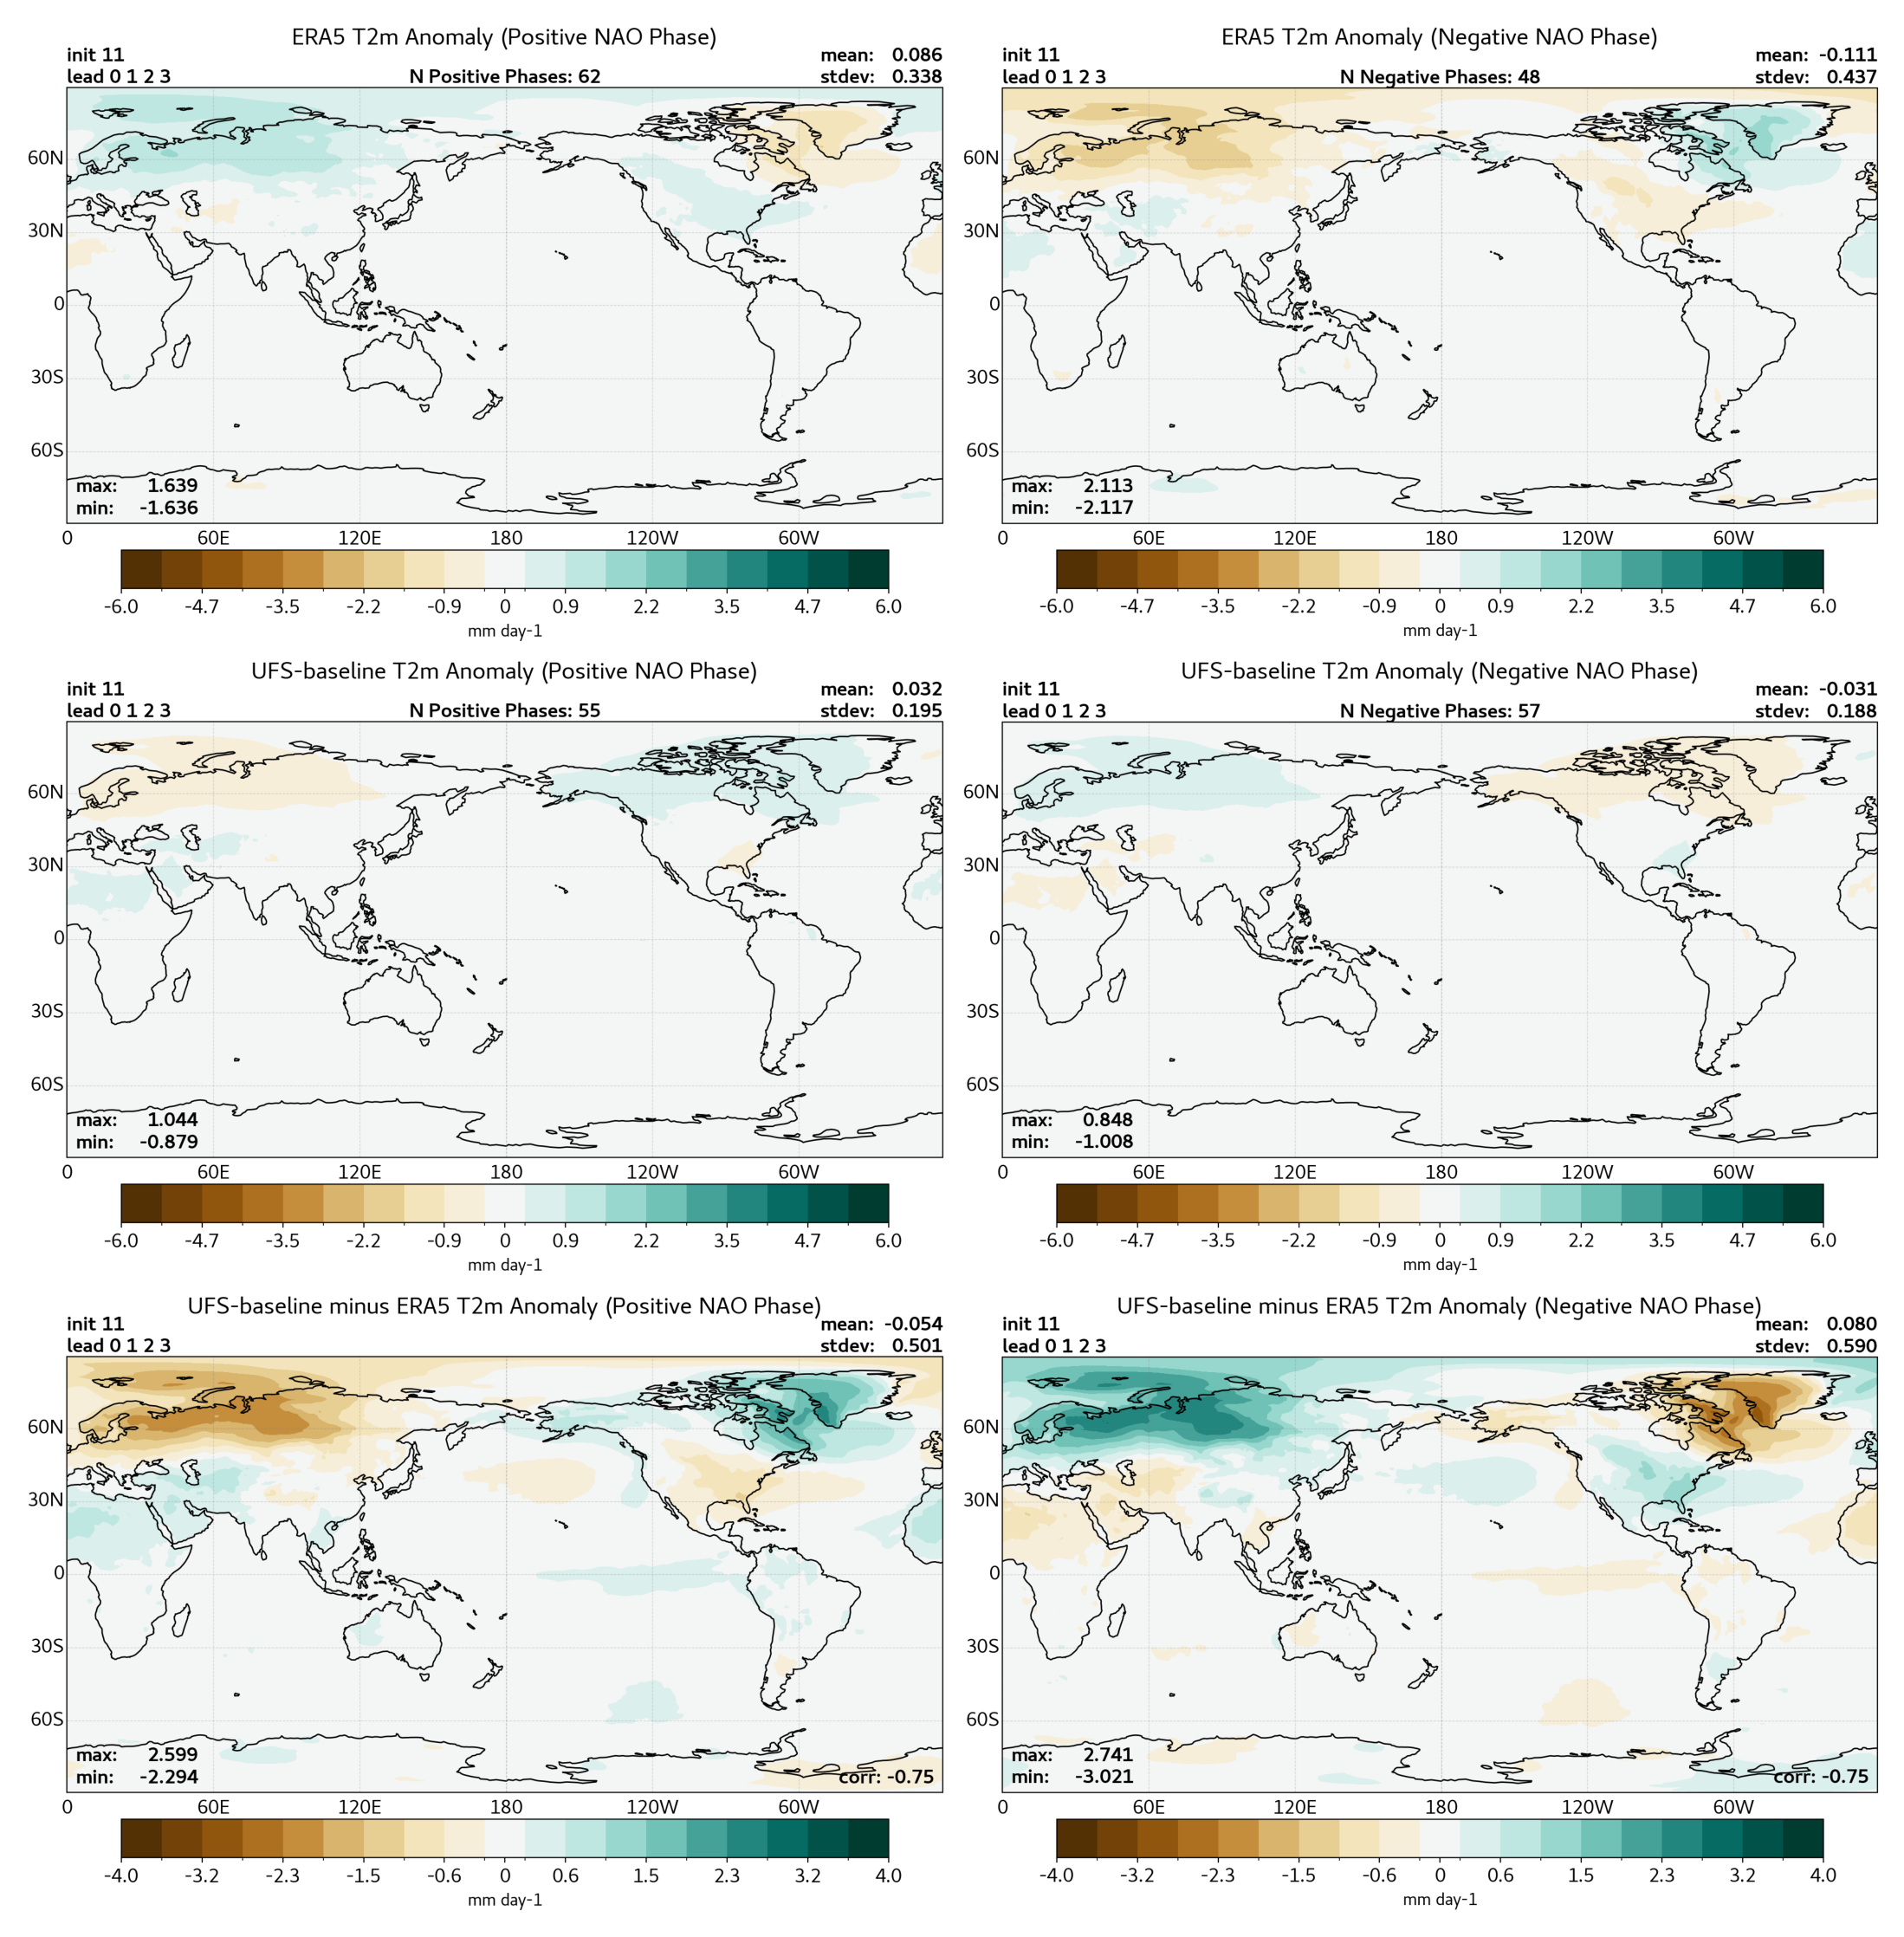

In [45]:
# Convert to images
image1 = Image.open(buffer1)
image2 = Image.open(buffer2)
image3 = Image.open(buffer3)
image4 = Image.open(buffer4)
image5 = Image.open(buffer5)
image6 = Image.open(buffer6)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 11), dpi=200)

axs[0, 0].imshow(image1)
axs[0, 0].axis('off')

axs[0, 1].imshow(image2)
axs[0, 1].axis('off')

axs[1, 0].imshow(image3)
axs[1, 0].axis('off')

axs[1, 1].imshow(image4)
axs[1, 1].axis('off')

axs[2, 0].imshow(image5)
axs[2, 0].axis('off')

axs[2, 1].imshow(image6)
axs[2, 1].axis('off')

plt.gca().set_frame_on(False)
plt.tight_layout(pad=.05)
plt.show()